# Opcode to Image Converter
Converts malware opcode sequences into grayscale images and saves them to `input/X_img.pt`.
Analogous to the byte-to-pixel visualisation method in Nguyen et al. (2023).

Run this notebook once before using the image mode in any training notebook.

In [1]:
import os
import zipfile
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

## Config

In [2]:
IMG_SIZE              = 64    # increased from 32 (captures 4096 opcodes vs 1024)
VOCAB_SIZE            = 300
MIN_SAMPLES_PER_CLASS = 25


## Build Image Cache
Converts opcode sequences into grayscale images and saves to `input/X_img.pt`.

| Cache state | Then |
|---|---|
| `input/X_img.pt` exists | skips, already done |
| `input/X.pt` exists (sequence cache) | converts sequences to images (like ~30s) |
| Neither exists | reads zip, filters families, builds images (slow takes ages, one-time run ;-;) |

**How the image is made:** each opcode is mapped to its vocab rank (1-300),
normalised to [0, 1], and arranged into an IMG_SIZE x IMG_SIZE grid.
Bright pixels = common opcodes, dark = rare or padding.

In [3]:
CACHE_X     = 'input/X.pt'
CACHE_Y     = 'input/y.pt'
CACHE_META  = 'input/meta.json'
CACHE_X_IMG = 'input/X_img.pt'

def seqs_to_images(seq_np, vocab_size, img_size):
    n_tokens = img_size * img_size
    n        = seq_np.shape[0]
    X_np     = np.zeros((n, n_tokens), dtype=np.float32)
    copy_len = min(seq_np.shape[1], n_tokens)
    X_np[:, :copy_len] = seq_np[:, :copy_len].astype(np.float32) / vocab_size
    return torch.from_numpy(X_np).reshape(n, 1, img_size, img_size)

if os.path.exists(CACHE_X_IMG):
    print(f'Image cache already exists at {CACHE_X_IMG} - nothing to do.')
    print('Delete it and re-run if you want to rebuild.')
    X = torch.load(CACHE_X_IMG)
    with open(CACHE_META) as f:
        meta = json.load(f)

elif os.path.exists(CACHE_X) and os.path.exists(CACHE_Y) and os.path.exists(CACHE_META):
    # ---- medium path: sequence cache exists ----
    print('Sequence cache found - converting to images (~30s)...')
    X_seq = torch.load(CACHE_X)
    with open(CACHE_META) as f:
        meta = json.load(f)
    X = seqs_to_images(X_seq.numpy(), meta['vocab_size'], IMG_SIZE)
    torch.save(X, CACHE_X_IMG)
    print(f'Saved {CACHE_X_IMG}')

else:
    # ---- slow path: read zip from scratch ----
    print('No cache found - reading from zip (one-time)...')

    rows, label_map = [], {}
    with zipfile.ZipFile('input/opcodes.zip') as z:
        entries = [e for e in z.infolist()
                   if not e.filename.endswith('/') and e.file_size > 0
                   and len(e.filename.split('/')) >= 3]
        print(f'  Reading {len(entries):,} files...')
        for i, entry in enumerate(entries):
            parts  = entry.filename.split('/')
            family = parts[1]
            if family not in label_map:
                label_map[family] = len(label_map)
            raw = z.read(entry.filename).decode('utf-8', errors='replace')
            rows.append({'opcodes': ' '.join(raw.split()), 'label': label_map[family]})
            if (i + 1) % 25000 == 0:
                print(f'    {i+1:,} / {len(entries):,} read...')
    df = pd.DataFrame(rows)

    # filter rare families
    counts        = df['label'].value_counts()
    keep          = counts[counts >= MIN_SAMPLES_PER_CLASS].index
    df            = df[df['label'].isin(keep)].copy()
    unique_labels = sorted(df['label'].unique())
    remap         = {old: new for new, old in enumerate(unique_labels)}
    df['label']   = df['label'].map(remap)
    label_map     = {fam: remap[i] for fam, i in label_map.items() if i in remap}
    print(f'  After filtering: {len(df):,} samples, {df["label"].nunique()} classes')

    # build vocab
    token_counts = Counter()
    for seq in df['opcodes']:
        token_counts.update(seq.split())
    most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
    token2idx   = {tok: i + 2 for i, tok in enumerate(most_common)}
    vocab_size  = len(token2idx) + 2

    # encode as images
    n_tokens     = IMG_SIZE * IMG_SIZE
    opcodes_list = df['opcodes'].tolist()
    n            = len(opcodes_list)
    X_np         = np.zeros((n, n_tokens), dtype=np.float32)
    print(f'  Encoding {n:,} sequences as {IMG_SIZE}x{IMG_SIZE} images...')
    for i, seq in enumerate(opcodes_list):
        tokens = seq.split()[:n_tokens]
        for j, t in enumerate(tokens):
            X_np[i, j] = token2idx.get(t, 1) / vocab_size
        if (i + 1) % 25000 == 0:
            print(f'    {i+1:,} / {n:,} done...')

    X           = torch.from_numpy(X_np).reshape(n, 1, IMG_SIZE, IMG_SIZE)
    y           = torch.tensor(df['label'].values, dtype=torch.long)
    num_classes = int(y.unique().size(0))
    meta        = {'vocab_size': vocab_size, 'num_classes': num_classes,
                   'label_map': label_map}

    torch.save(X, CACHE_X_IMG)
    torch.save(y, CACHE_Y)
    with open(CACHE_META, 'w') as f:
        json.dump(meta, f)
    print(f'  Saved {CACHE_X_IMG}, {CACHE_Y}, {CACHE_META}')

print(f'\nDone - {X.shape[0]:,} images | shape {tuple(X.shape[1:])} | values [{X.min():.2f}, {X.max():.2f}]')

Sequence cache found - converting to images (~30s)...
Saved input/X_img.pt

Done - 212,864 images | shape (1, 64, 64) | values [0.00, 1.00]


## Sample Images
Shows one example image per family (first 16) so you can verify the conversion looks correct.

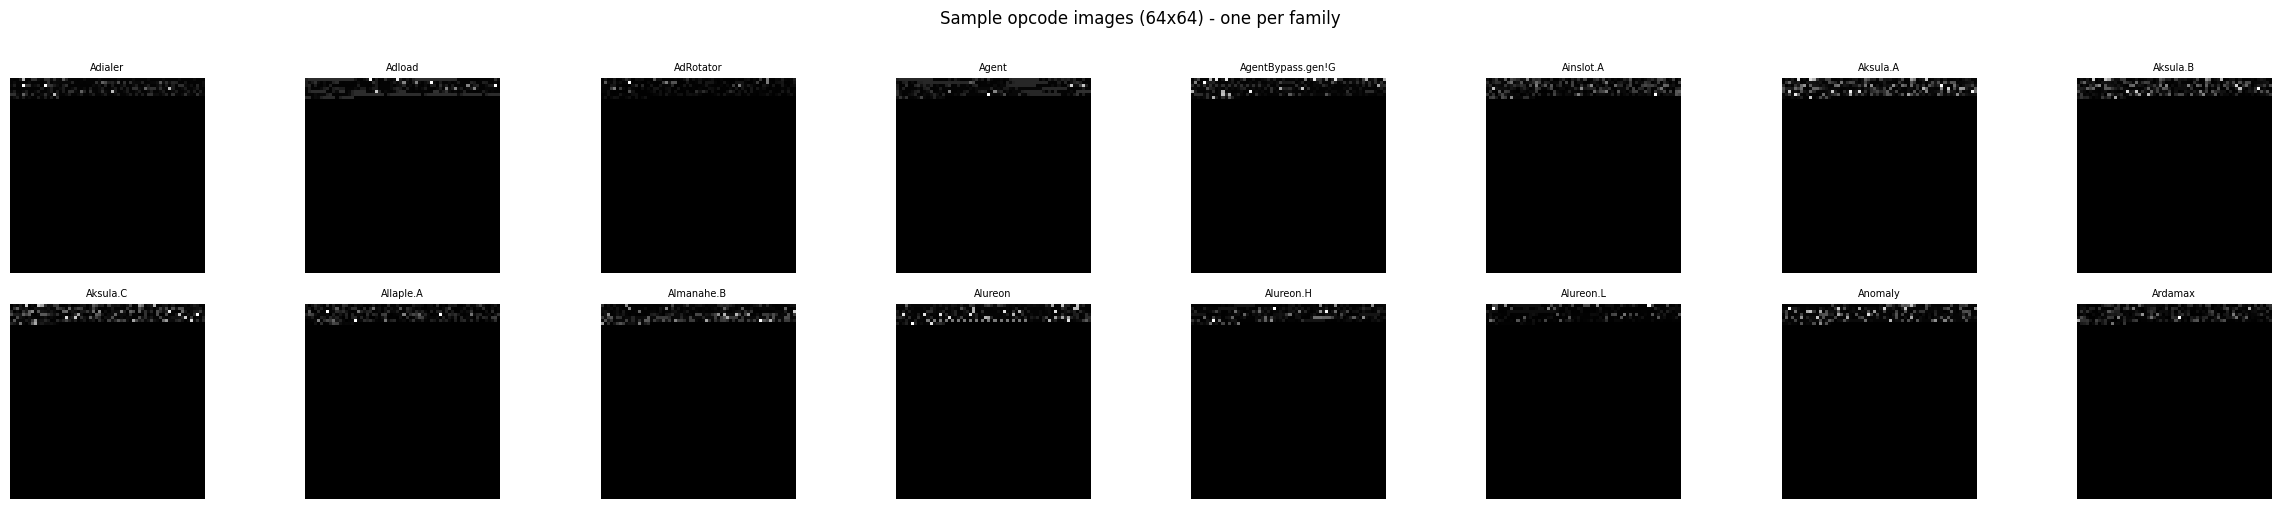

Saved output/sample_images.png


In [4]:
y           = torch.load(CACHE_Y)
label_map   = meta['label_map']
num_classes = meta['num_classes']
inv_label   = {v: k for k, v in label_map.items()}

n_show = min(16, num_classes)
fig, axes = plt.subplots(2, n_show // 2, figsize=(n_show * 1.5, 5))
axes = axes.flatten()

for class_id in range(n_show):
    mask = (y == class_id).nonzero(as_tuple=True)[0]
    img  = X[mask[0]].squeeze().numpy()
    axes[class_id].imshow(img, cmap='gray', interpolation='nearest')
    axes[class_id].set_title(inv_label.get(class_id, str(class_id)), fontsize=7)
    axes[class_id].axis('off')

plt.suptitle(f'Sample opcode images ({IMG_SIZE}x{IMG_SIZE}) - one per family', y=1.01)
plt.tight_layout()
plt.savefig('output/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved output/sample_images.png')